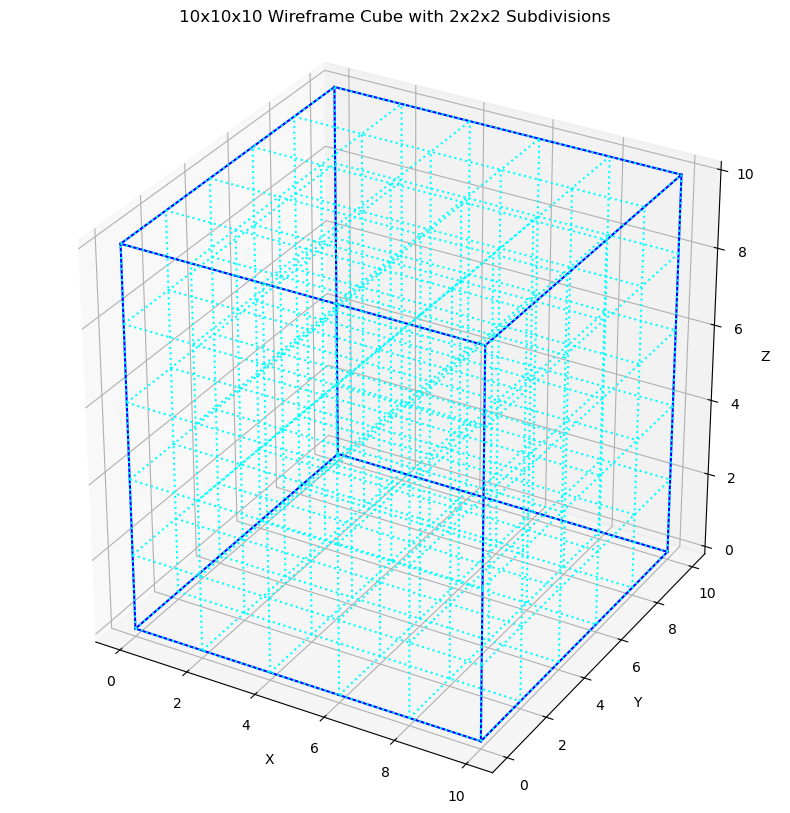

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define the dimensions of the cube
CUBE_SIZE = 10
SUBDIVISION_SIZE = 2

# Create a figure and a 3D axis
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# --- 1. Create the main 10x10x10 wireframe ---

# Define the 8 vertices of the cube
vertices = np.array([
    [0, 0, 0],
    [CUBE_SIZE, 0, 0],
    [CUBE_SIZE, CUBE_SIZE, 0],
    [0, CUBE_SIZE, 0],
    [0, 0, CUBE_SIZE],
    [CUBE_SIZE, 0, CUBE_SIZE],
    [CUBE_SIZE, CUBE_SIZE, CUBE_SIZE],
    [0, CUBE_SIZE, CUBE_SIZE]
])

# Define the 12 edges of the cube
edges = [
    (0, 1), (1, 2), (2, 3), (3, 0),  # Bottom face
    (4, 5), (5, 6), (6, 7), (7, 4),  # Top face
    (0, 4), (1, 5), (2, 6), (3, 7)   # Vertical edges
]

# Plot the main cube edges
for edge in edges:
    points = vertices[list(edge)]
    ax.plot3D(points[:, 0], points[:, 1], points[:, 2], 'blue')

# --- 2. Create the 2x2x2 subdivisions ---

# Lines along the X-axis
for y in np.arange(0, CUBE_SIZE + SUBDIVISION_SIZE, SUBDIVISION_SIZE):
    for z in np.arange(0, CUBE_SIZE + SUBDIVISION_SIZE, SUBDIVISION_SIZE):
        ax.plot3D([0, CUBE_SIZE], [y, y], [z, z], 'cyan', linestyle=':')

# Lines along the Y-axis
for x in np.arange(0, CUBE_SIZE + SUBDIVISION_SIZE, SUBDIVISION_SIZE):
    for z in np.arange(0, CUBE_SIZE + SUBDIVISION_SIZE, SUBDIVISION_SIZE):
        ax.plot3D([x, x], [0, CUBE_SIZE], [z, z], 'cyan', linestyle=':')

# Lines along the Z-axis
for x in np.arange(0, CUBE_SIZE + SUBDIVISION_SIZE, SUBDIVISION_SIZE):
    for y in np.arange(0, CUBE_SIZE + SUBDIVISION_SIZE, SUBDIVISION_SIZE):
        ax.plot3D([x, x], [y, y], [0, CUBE_SIZE], 'cyan', linestyle=':')


# --- 3. Set plot properties ---
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('10x10x10 Wireframe Cube with 2x2x2 Subdivisions')

# Set equal aspect ratio
ax.set_box_aspect([1, 1, 1])

plt.show()


Trajectory went through the following unit cubes (ix, iy, iz):
[(3, 4.0, 1), (2, 4.0, 1), (2, 4.0, 2), (2, 3.0, 2), (2, 3.0, 3), (2, 2.0, 3), (1, 2.0, 3), (1, 2.0, 4), (1, 1.0, 4), (0, 1.0, 4), (0, 0.0, 4)]


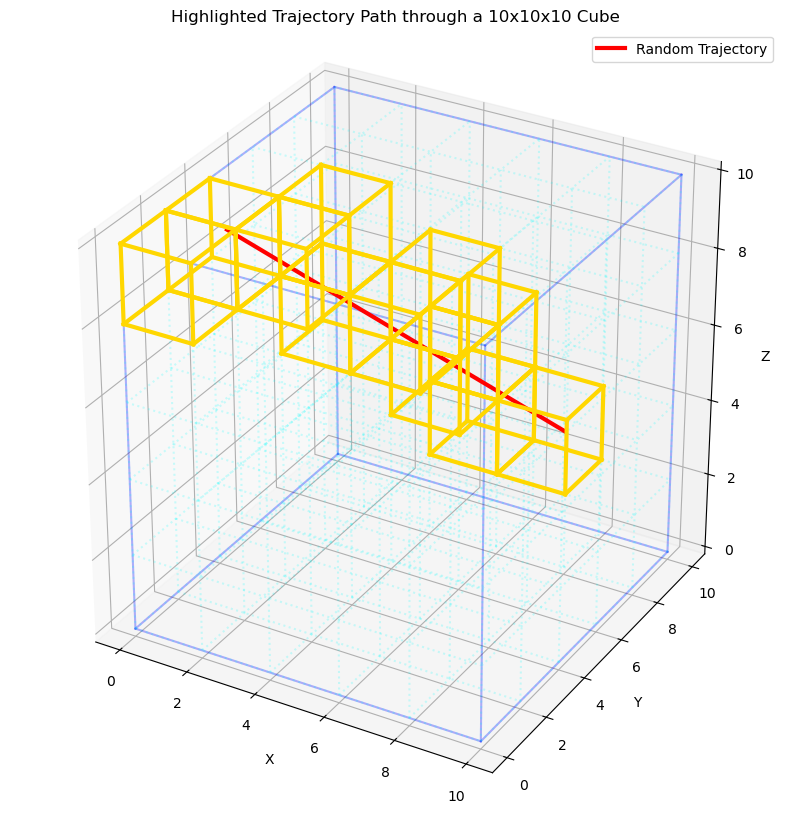

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import math

# Define the dimensions of the cube
CUBE_SIZE = 10
SUBDIVISION_SIZE = 2

# --- 1. New Function to find traversed units ---

def get_traversed_units(p1, p2, cube_dim, sub_dim):
    """
    Calculates the grid coordinates of all unit cubes a line segment passes through.
    Uses an implementation of the Amanatides & Woo fast voxel traversal algorithm.
    """
    # Convert world coordinates to grid coordinates
    x1, y1, z1 = p1
    x2, y2, z2 = p2
    
    ix = math.floor(x1 / sub_dim)
    iy = math.floor(y1 / sub_dim)
    iz = math.floor(z1 / sub_dim)
    
    # Ensure starting point is within the grid bounds
    ix = max(0, min(ix, (cube_dim / sub_dim) - 1))
    iy = max(0, min(iy, (cube_dim / sub_dim) - 1))
    iz = max(0, min(iz, (cube_dim / sub_dim) - 1))

    # Direction of the line
    dx = x2 - x1
    dy = y2 - y1
    dz = z2 - z1
    
    # Step direction (1, -1, or 0)
    stepX = int(np.sign(dx))
    stepY = int(np.sign(dy))
    stepZ = int(np.sign(dz))
    
    # t values for crossing next grid boundaries
    next_boundary_x = (ix + (1 if stepX > 0 else 0)) * sub_dim
    next_boundary_y = (iy + (1 if stepY > 0 else 0)) * sub_dim
    next_boundary_z = (iz + (1 if stepZ > 0 else 0)) * sub_dim
    
    # Calculate tMax - the t value at which the ray crosses the next boundary
    tMaxX = (next_boundary_x - x1) / dx if dx != 0 else float('inf')
    tMaxY = (next_boundary_y - y1) / dy if dy != 0 else float('inf')
    tMaxZ = (next_boundary_z - z1) / dz if dz != 0 else float('inf')
    
    # Calculate tDelta - the t value needed to travel one full grid unit
    tDeltaX = sub_dim / abs(dx) if dx != 0 else float('inf')
    tDeltaY = sub_dim / abs(dy) if dy != 0 else float('inf')
    tDeltaZ = sub_dim / abs(dz) if dz != 0 else float('inf')
    
    traversed = [(ix, iy, iz)]
    
    # The end grid cell
    end_ix = math.floor(x2 / sub_dim)
    end_iy = math.floor(y2 / sub_dim)
    end_iz = math.floor(z2 / sub_dim)
    
    # Clamp end point to be within bounds, in case line extends past the cube
    end_ix = max(0, min(end_ix, (cube_dim / sub_dim) - 1))
    end_iy = max(0, min(end_iy, (cube_dim / sub_dim) - 1))
    end_iz = max(0, min(end_iz, (cube_dim / sub_dim) - 1))

    while (ix, iy, iz) != (end_ix, end_iy, end_iz):
        if tMaxX < tMaxY:
            if tMaxX < tMaxZ:
                ix += stepX
                tMaxX += tDeltaX
            else:
                iz += stepZ
                tMaxZ += tDeltaZ
        else:
            if tMaxY < tMaxZ:
                iy += stepY
                tMaxY += tDeltaY
            else:
                iz += stepZ
                tMaxZ += tDeltaZ

        # Check for infinite loops or out of bounds
        if not (0 <= ix < cube_dim/sub_dim and 0 <= iy < cube_dim/sub_dim and 0 <= iz < cube_dim/sub_dim):
            break
            
        traversed.append((ix, iy, iz))
        
    return traversed


# --- Main script ---

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# --- Plot the main wireframe and subdivisions (unchanged) ---
vertices = np.array([
    [0, 0, 0], [CUBE_SIZE, 0, 0], [CUBE_SIZE, CUBE_SIZE, 0], [0, CUBE_SIZE, 0],
    [0, 0, CUBE_SIZE], [CUBE_SIZE, 0, CUBE_SIZE], [CUBE_SIZE, CUBE_SIZE, CUBE_SIZE], [0, CUBE_SIZE, CUBE_SIZE]
])
edges = [
    (0, 1), (1, 2), (2, 3), (3, 0), (4, 5), (5, 6), (6, 7), (7, 4),
    (0, 4), (1, 5), (2, 6), (3, 7)
]
for edge in edges:
    points = vertices[list(edge)]
    ax.plot3D(points[:, 0], points[:, 1], points[:, 2], 'blue', alpha=0.3)

for x in np.arange(0, CUBE_SIZE + SUBDIVISION_SIZE, SUBDIVISION_SIZE):
    for y in np.arange(0, CUBE_SIZE + SUBDIVISION_SIZE, SUBDIVISION_SIZE):
        ax.plot3D([x, x], [y, y], [0, CUBE_SIZE], 'cyan', linestyle=':', alpha=0.2)
for y in np.arange(0, CUBE_SIZE + SUBDIVISION_SIZE, SUBDIVISION_SIZE):
    for z in np.arange(0, CUBE_SIZE + SUBDIVISION_SIZE, SUBDIVISION_SIZE):
        ax.plot3D([0, CUBE_SIZE], [y, y], [z, z], 'cyan', linestyle=':', alpha=0.2)
for x in np.arange(0, CUBE_SIZE + SUBDIVISION_SIZE, SUBDIVISION_SIZE):
    for z in np.arange(0, CUBE_SIZE + SUBDIVISION_SIZE, SUBDIVISION_SIZE):
        ax.plot3D([x, x], [0, CUBE_SIZE], [z, z], 'cyan', linestyle=':', alpha=0.2)


# --- Create a random trajectory (unchanged) ---
def get_random_point_on_face(cube_dim):
    face = np.random.randint(0, 6)
    rand_coords = np.random.uniform(0, cube_dim, 2)
    if face == 0: return [0, rand_coords[0], rand_coords[1]]
    if face == 1: return [cube_dim, rand_coords[0], rand_coords[1]]
    if face == 2: return [rand_coords[0], 0, rand_coords[1]]
    if face == 3: return [rand_coords[0], cube_dim, rand_coords[1]]
    if face == 4: return [rand_coords[0], rand_coords[1], 0]
    if face == 5: return [rand_coords[0], rand_coords[1], cube_dim]

start_point = get_random_point_on_face(CUBE_SIZE)
end_point = get_random_point_on_face(CUBE_SIZE)
ax.plot3D([start_point[0], end_point[0]], [start_point[1], end_point[1]], [start_point[2], end_point[2]], 'red', linewidth=3, label='Random Trajectory')


# --- 2. Get and highlight the traversed units ---
traversed_units = get_traversed_units(start_point, end_point, CUBE_SIZE, SUBDIVISION_SIZE)

print("Trajectory went through the following unit cubes (ix, iy, iz):")
print(traversed_units)

# Define the edges of a single unit cube for drawing
unit_verts = np.array([
    [0,0,0], [1,0,0], [1,1,0], [0,1,0],
    [0,0,1], [1,0,1], [1,1,1], [0,1,1]
]) * SUBDIVISION_SIZE
unit_edges = [(0,1), (1,2), (2,3), (3,0), (4,5), (5,6), (6,7), (7,4), (0,4), (1,5), (2,6), (3,7)]

# Plot each traversed unit
for unit_coords in traversed_units:
    ix, iy, iz = unit_coords
    offset = np.array([ix, iy, iz]) * SUBDIVISION_SIZE
    for edge in unit_edges:
        points = unit_verts[list(edge)] + offset
        ax.plot3D(points[:, 0], points[:, 1], points[:, 2], 'gold', linewidth=3)

# --- Set plot properties (unchanged) ---
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Highlighted Trajectory Path through a 10x10x10 Cube')
ax.legend()
ax.set_box_aspect([1, 1, 1])
plt.show()



Initializing Visual Damage Assessment...
Superstructure Blob: HIT


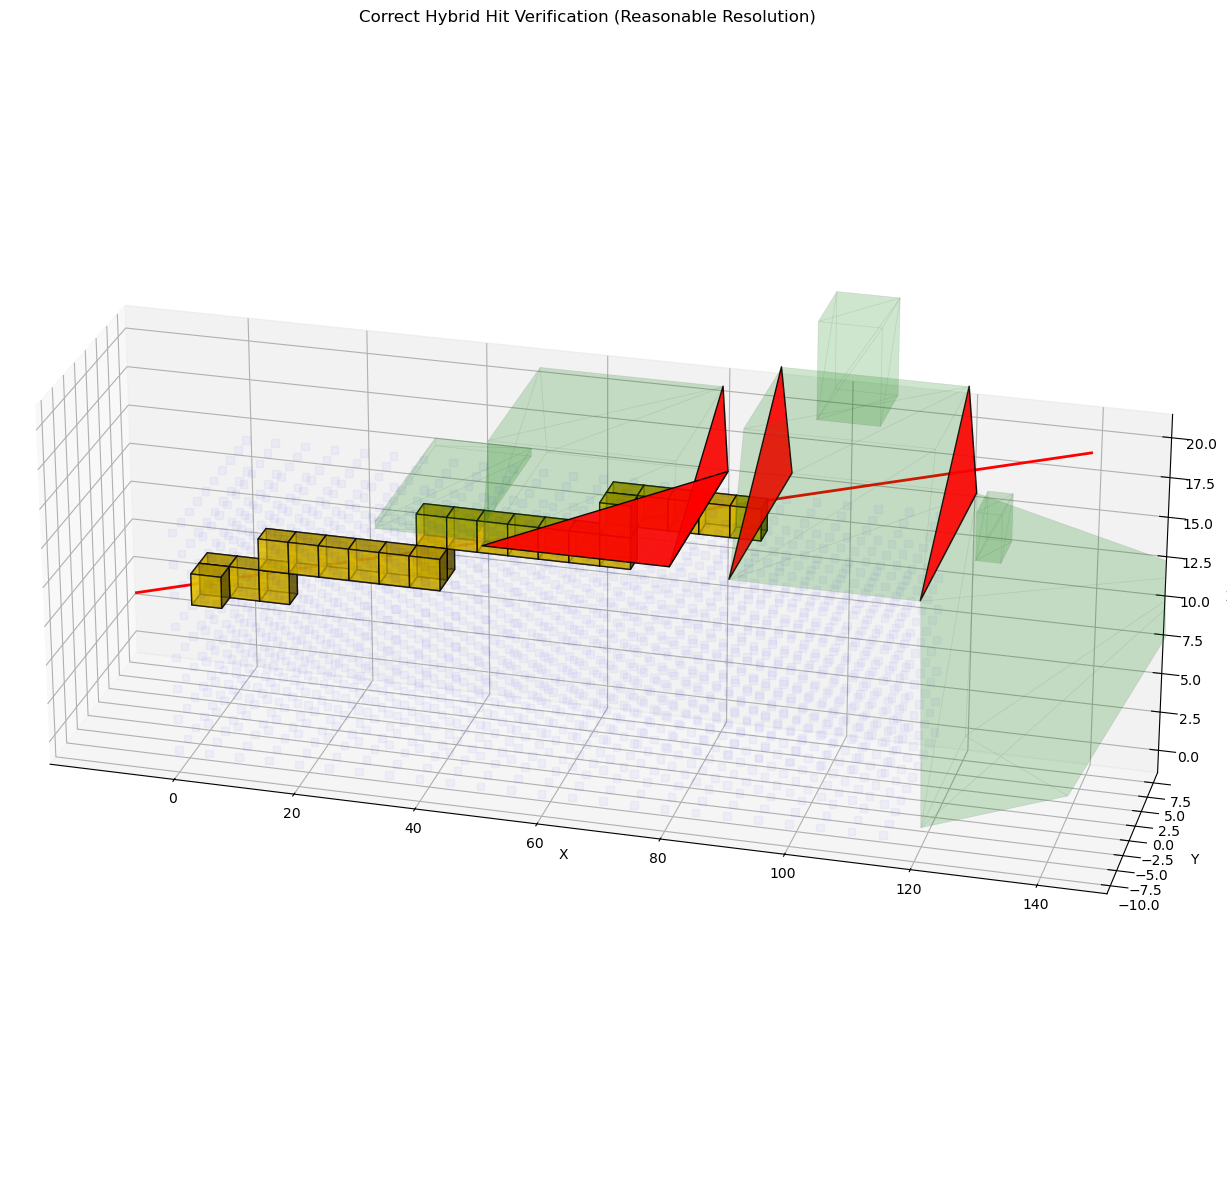

In [ ]:
import numpy as np
import time
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D, art3d

# --- Ship Model Definition (unchanged) ---
main_deck_height = 15; helipad_height = 10; helipad_end_x = 30; main_body_end_x = 120
bow_start_x = 120; bow_top_end_x = 160; bow_bottom_end_x = 140
ship_model = { "main_hull": { "v": { "sb": np.array([0, -8, 0]), "ss": np.array([0, 8, 0]), "fb": np.array([main_body_end_x, -8, 0]), "fs": np.array([main_body_end_x, 8, 0]), "hps": np.array([0, -10, helipad_height]), "hss": np.array([0, 10, helipad_height]), "hpf": np.array([helipad_end_x, -10, helipad_height]), "hsf": np.array([helipad_end_x, 10, helipad_height]), "maf": np.array([helipad_end_x, -10, main_deck_height]), "msf": np.array([helipad_end_x, 10, main_deck_height]), "mff": np.array([main_body_end_x, -10, main_deck_height]), "msff": np.array([main_body_end_x, 10, main_deck_height]), }, "e": [], "lw": 2, }, "bow": { "v": { "base_port_bottom": np.array([bow_start_x, -8, 0]), "base_stbd_bottom": np.array([bow_start_x, 8, 0]), "base_port_top": np.array([bow_start_x, -10, main_deck_height]), "base_stbd_top": np.array([bow_start_x, 10, main_deck_height]), "tip_bottom": np.array([bow_bottom_end_x, 0, 0]), "tip_top": np.array([bow_top_end_x, 0, main_deck_height]) }, "e": [], "lw": 2, }, "gun": { "v": { "blb": np.array([125, -2, main_deck_height]), "brb": np.array([125, 2, main_deck_height]), "flb": np.array([129, -2, main_deck_height]), "frb": np.array([129, 2, main_deck_height]), "blt": np.array([125, -2, main_deck_height + 3]), "brt": np.array([125, 2, main_deck_height + 3]), "flt": np.array([129, -2, main_deck_height + 3]), "frt": np.array([129, 2, main_deck_height + 3]), }, "e": [], "lw": 1.5, }, "aft_vls": { "v": { "blb": np.array([32, -8, main_deck_height]), "brb": np.array([32, 8, main_deck_height]), "flb": np.array([48, -8, main_deck_height]), "frb": np.array([48, 8, main_deck_height]), "blt": np.array([32, -8, main_deck_height + 0.5]), "brt": np.array([32, 8, main_deck_height + 0.5]), "flt": np.array([48, -8, main_deck_height + 0.5]), "frt": np.array([48, 8, main_deck_height + 0.5]), }, "e": [], "lw": 1.5, }, "aft_superstructure": { "v": { "blb": np.array([50, -9, main_deck_height]), "brb": np.array([50, 9, main_deck_height]), "flb": np.array([80, -9, main_deck_height]), "frb": np.array([80, 9, main_deck_height]), "blt": np.array([50, -7.2, main_deck_height + 6]), "brt": np.array([50, 7.2, main_deck_height + 6]), "flt": np.array([80, -7.2, main_deck_height + 6]), "frt": np.array([80, 7.2, main_deck_height + 6]), }, "e": [], "lw": 2, }, "bridge": { "v": { "blb": np.array([90, -10, main_deck_height]), "brb": np.array([90, 10, main_deck_height]), "flb": np.array([120, -10, main_deck_height]), "frb": np.array([120, 10, main_deck_height]), "blt": np.array([90, -6, main_deck_height + 8]), "brt": np.array([90, 6, main_deck_height + 8]), "flt": np.array([120, -6, main_deck_height + 8]), "frt": np.array([120, 6, main_deck_height + 8]), }, "e": [], "lw": 2, }, "mast": { "v": { "blb": np.array([100, -3, main_deck_height + 8]), "brb": np.array([100, 3, main_deck_height + 8]), "flb": np.array([110, -3, main_deck_height + 8]), "frb": np.array([110, 3, main_deck_height + 8]), "blt": np.array([100, -3, main_deck_height + 14]), "brt": np.array([100, 3, main_deck_height + 14]), "flt": np.array([110, -3, main_deck_height + 14]), "frt": np.array([110, 3, main_deck_height + 14]), }, "e": [], "lw": 1.5, }}

# --- CORE ALGORITHMS & SETUP (Identical to Script 1) ---
def get_traversed_units(p1, p2, origin, grid_dims, resolution):
    res = resolution
    ix,iy,iz = (int(math.floor((c-o)/r)) for c,o,r in zip(p1,origin,res)); end_ix,end_iy,end_iz = (int(math.floor((c-o)/r)) for c,o,r in zip(p2,origin,res))
    ix,iy,iz = max(0,min(ix,grid_dims[0]-1)),max(0,min(iy,grid_dims[1]-1)),max(0,min(iz,grid_dims[2]-1))
    end_ix,end_iy,end_iz = max(0,min(end_ix,grid_dims[0]-1)),max(0,min(end_iy,grid_dims[1]-1)),max(0,min(end_iz,grid_dims[2]-1))
    dx,dy,dz = p2-p1; stepX,stepY,stepZ = (int(np.sign(d)) for d in [dx,dy,dz])
    next_bx,next_by,next_bz = (((i+(1 if s>0 else 0))*r)+o for i,s,o,r in zip((ix,iy,iz),(stepX,stepY,stepZ),origin,res))
    tMaxX,tMaxY,tMaxZ = (((nb-c)/d) if d!=0 else float('inf') for nb,c,d in zip((next_bx,next_by,next_bz),p1,(dx,dy,dz)))
    tDeltaX,tDeltaY,tDeltaZ = ((r/abs(d)) if d!=0 else float('inf') for d,r in zip((dx,dy,dz),res))
    traversed = [(ix,iy,iz)]
    while (ix,iy,iz) != (end_ix,end_iy,end_iz):
        if tMaxX<tMaxY:
            if tMaxX<tMaxZ: ix+=stepX; tMaxX+=tDeltaX
            else: iz+=stepZ; tMaxZ+=tDeltaZ
        else:
            if tMaxY<tMaxZ: iy+=stepY; tMaxY+=tDeltaY
            else: iz+=stepZ; tMaxZ+=tDeltaZ
        if not (0<=ix<grid_dims[0] and 0<=iy<grid_dims[1] and 0<=iz<grid_dims[2]): break
        traversed.append((ix,iy,iz))
    return set(traversed)

def segment_triangle_intersect(p1, p2, tri):
    v0, v1, v2 = tri; direction = p2 - p1; edge1 = v1 - v0; edge2 = v2 - v0
    h = np.cross(direction, edge2); a = np.dot(edge1, h)
    if -1e-7 < a < 1e-7: return False
    f = 1.0 / a; s = p1 - v0; u = f * np.dot(s, h)
    if u < 0.0 or u > 1.0: return False
    q = np.cross(s, edge1); v = f * np.dot(direction, q)
    if v < 0.0 or u + v > 1.0: return False
    t = f * np.dot(edge2, q)
    return 0.0 < t < 1.0

def setup_ship_model(model_data, hull_resolution):
    hull_verts = np.array(list(model_data['main_hull']['v'].values())); min_h, max_h = hull_verts.min(axis=0), hull_verts.max(axis=0)
    hull_indices, hull_voxels = set(), []
    for x in np.arange(min_h[0], max_h[0], hull_resolution[0]):
        for y in np.arange(min_h[1], max_h[1], hull_resolution[1]):
            for z in np.arange(min_h[2], max_h[2], hull_resolution[2]):
                ix,iy,iz = (int((x-min_h[0])/hull_resolution[0])), int((y-min_h[1])/hull_resolution[1]), int((z-min_h[2])/hull_resolution[2])
                hull_indices.add((ix,iy,iz)); hull_voxels.append([x,y,z])
    hull_grid_dims = [int(math.ceil((max_h[i]-min_h[i])/hull_resolution[i])) for i in range(3)]
    hull_data = {"stats": {'total_cells': len(hull_indices), 'indices': hull_indices, 'voxels': np.array(hull_voxels)}, "grid_dims": hull_grid_dims, "resolution": hull_resolution, "origin": min_h}

    superstructure_components = {k:v for k,v in model_data.items() if k != 'main_hull'}
    superstructure_triangles = []
    for name, comp_data in superstructure_components.items():
        v = comp_data['v']; faces = []
        if name == 'bow': faces = [(v['base_port_bottom'],v['base_stbd_bottom'],v['tip_bottom']), (v['base_port_top'],v['base_stbd_top'],v['tip_top']), (v['base_port_bottom'],v['base_port_top'],v['tip_top'],v['tip_bottom']), (v['base_stbd_bottom'],v['base_stbd_top'],v['tip_top'],v['tip_bottom']), (v['base_port_bottom'],v['base_stbd_bottom'],v['base_stbd_top'],v['base_port_top'])]
        else: faces = [(v['blb'],v['brb'],v['frb'],v['flb']), (v['blt'],v['brt'],v['frt'],v['flt']), (v['blb'],v['blt'],v['flt'],v['flb']), (v['brb'],v['brt'],v['frt'],v['frb']), (v['blb'],v['brb'],v['brt'],v['blt']), (v['flb'],v['frb'],v['frt'],v['flt'])]
        for face in faces:
            if len(face) == 4: superstructure_triangles.extend([(face[0], face[1], face[2]), (face[0], face[2], face[3])])
            else: superstructure_triangles.append(face)
    return { "hull_data": hull_data, "superstructure_triangles": superstructure_triangles }

# --- VISUALIZATION SCRIPT ---
def main_visualizer():
    print("Initializing Visual Damage Assessment...")
    # --- UPDATED with reasonable resolution ---
    ship_data = setup_ship_model(ship_model, hull_resolution=[5.0, 2.0, 2.0])
    
    start_point = np.array([-10, -5, 8]); end_point = np.array([140, 5, 20])
    
    hull_data = ship_data['hull_data']
    path_indices = get_traversed_units(start_point, end_point, hull_data['origin'], hull_data['grid_dims'], hull_data['resolution'])
    hull_hit_indices = path_indices.intersection(hull_data['stats']['indices'])
    
    superstructure_hit = False
    hit_triangles = []
    for tri in ship_data['superstructure_triangles']:
        if segment_triangle_intersect(start_point, end_point, tri):
            superstructure_hit = True
            hit_triangles.append(tri)
    
    fig = plt.figure(figsize=(20, 15)); ax = fig.add_subplot(111, projection='3d')

    hull_voxels = hull_data['stats']['voxels']
    if hull_voxels.size > 0: ax.scatter(hull_voxels[:,0], hull_voxels[:,1], hull_voxels[:,2], c='blue', alpha=0.03, marker='s', s=30)

    for tri in ship_data['superstructure_triangles']:
        face = art3d.Poly3DCollection([tri], alpha=0.1, facecolor='green', edgecolor='gray', lw=0.5)
        ax.add_collection3d(face)
        
    ax.plot([start_point[0], end_point[0]], [start_point[1], end_point[1]], [start_point[2], end_point[2]], 'r-', lw=2, label='Trajectory')

    hull_res = hull_data['resolution']; origin_h = hull_data['origin']
    for ix,iy,iz in hull_hit_indices:
        x,y,z = origin_h[0]+ix*hull_res[0], origin_h[1]+iy*hull_res[1], origin_h[2]+iz*hull_res[2]
        ax.bar3d(x, y, z, hull_res[0], hull_res[1], hull_res[2], color='gold', alpha=0.7, edgecolor='k')
        
    if superstructure_hit:
        face_collection = art3d.Poly3DCollection(hit_triangles, alpha=0.9, facecolor='red', edgecolor='black', lw=1)
        ax.add_collection3d(face_collection)
        print("Superstructure Blob: HIT")
    else:
        print("Superstructure Blob: No Hit")
    
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z'); ax.set_title('Correct Hybrid Hit Verification (Reasonable Resolution)')
    all_verts_np = np.vstack([v for comp in ship_model.values() for v in comp['v'].values()])
    ax.set_box_aspect((np.ptp(all_verts_np[:,0]), np.ptp(all_verts_np[:,1])*2, np.ptp(all_verts_np[:,2])*2))
    ax.view_init(elev=25, azim=-75)
    plt.show()

if __name__ == "__main__":
    main_visualizer()
